  [Lake Erie Median] Complete Feature Metrics (Sorted by R2)  
            Feature  RF_Importance  Correlation (r)  R2_Score
              B5/B4       0.220309         0.594617  0.353569
    (B4-B5)/(B4+B5)       0.117416        -0.568951  0.323705
              B4/B5       0.082867        -0.532443  0.283496
              B3/B2       0.063260         0.479576  0.229993
    (B2-B3)/(B2+B3)       0.030084        -0.445642  0.198596
              B5/B2       0.007079         0.428155  0.183317
              B2/B3       0.036332        -0.416101  0.173140
    (B2-B5)/(B2+B5)       0.008660        -0.390281  0.152319
  (B5-B8A)/(B5+B8A)       0.002597         0.332779  0.110742
             B7/B8A       0.004737         0.331717  0.110036
  (B7-B8A)/(B7+B8A)       0.002426         0.327264  0.107102
             B8A/B5       0.002585        -0.324126  0.105058
             B8A/B7       0.002574        -0.321879  0.103606
    (B5-B6)/(B5+B6)       0.002613         0.318491  0.101437
       

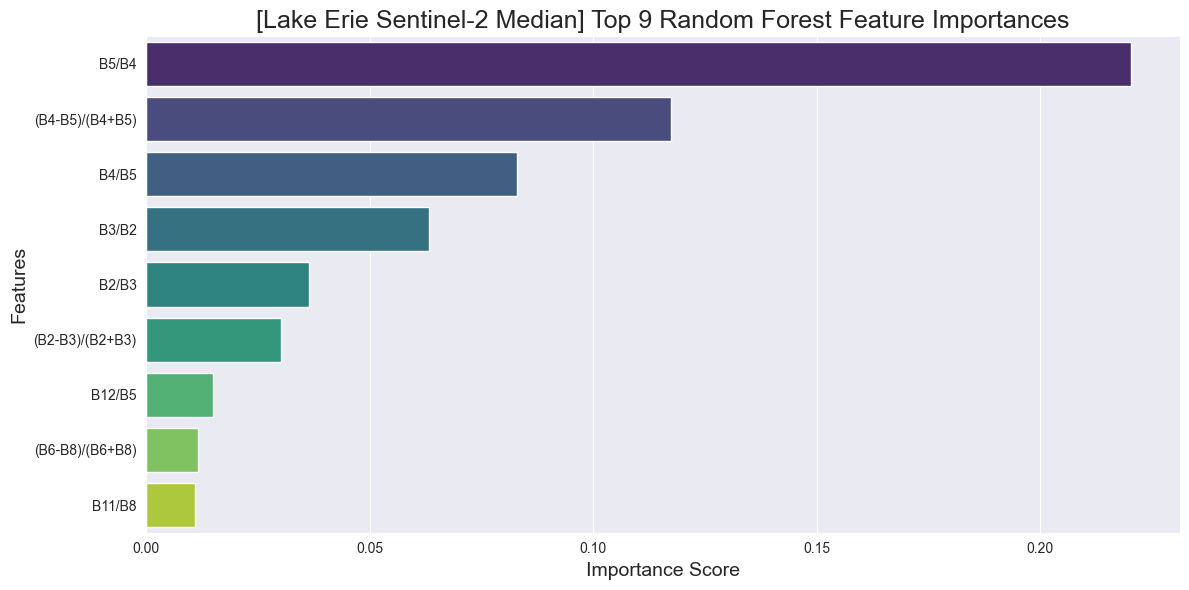

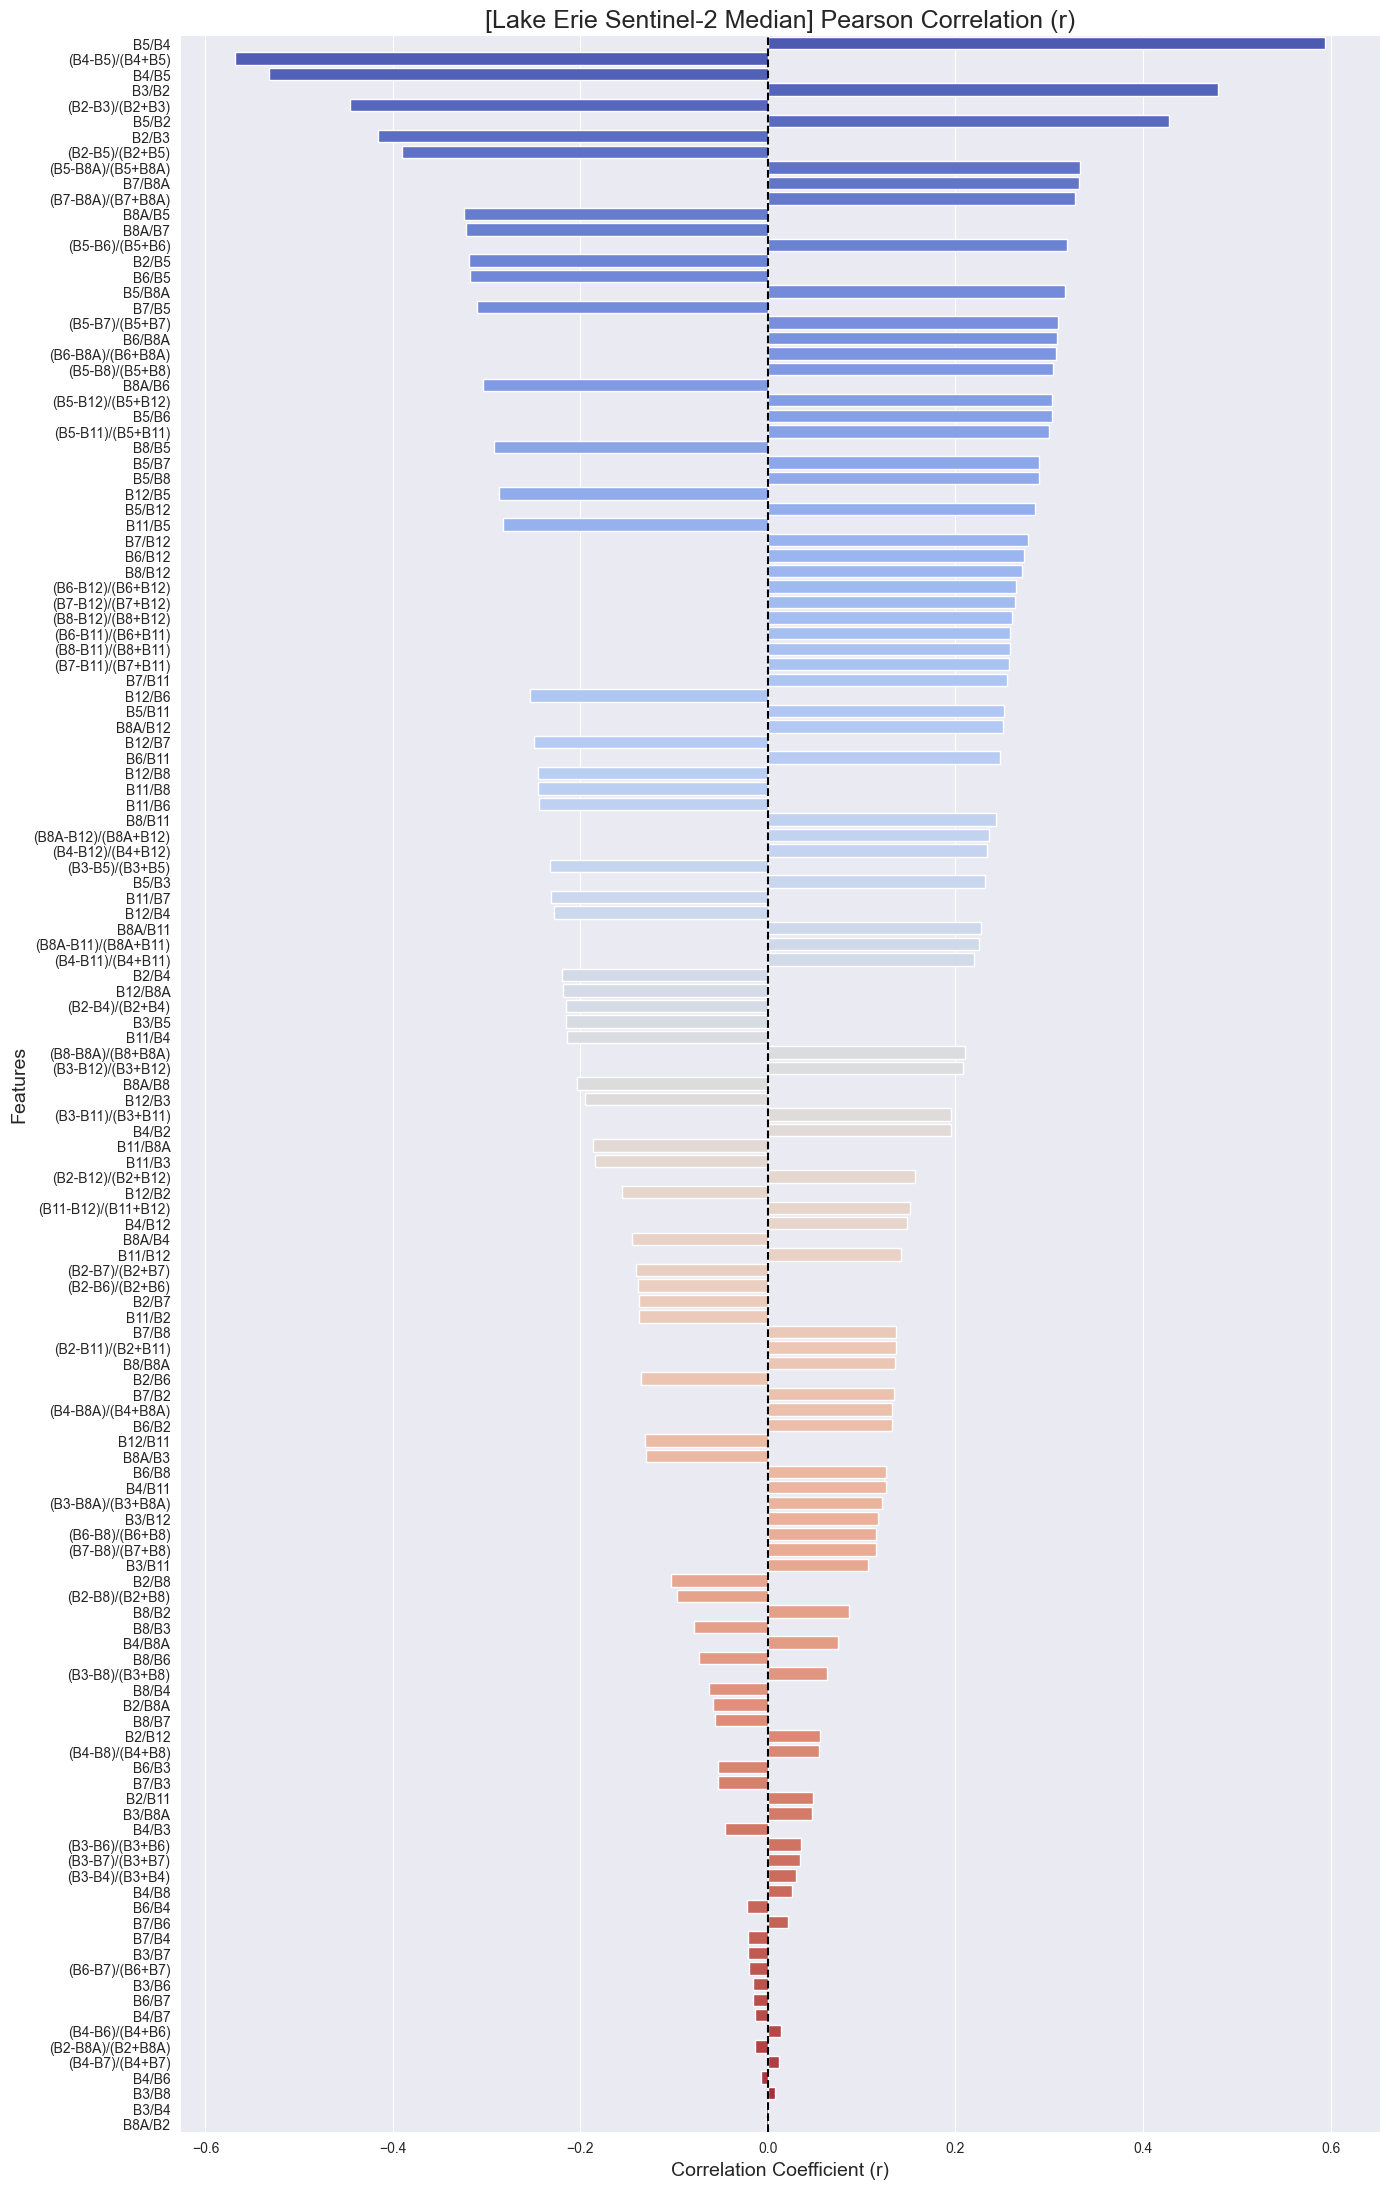

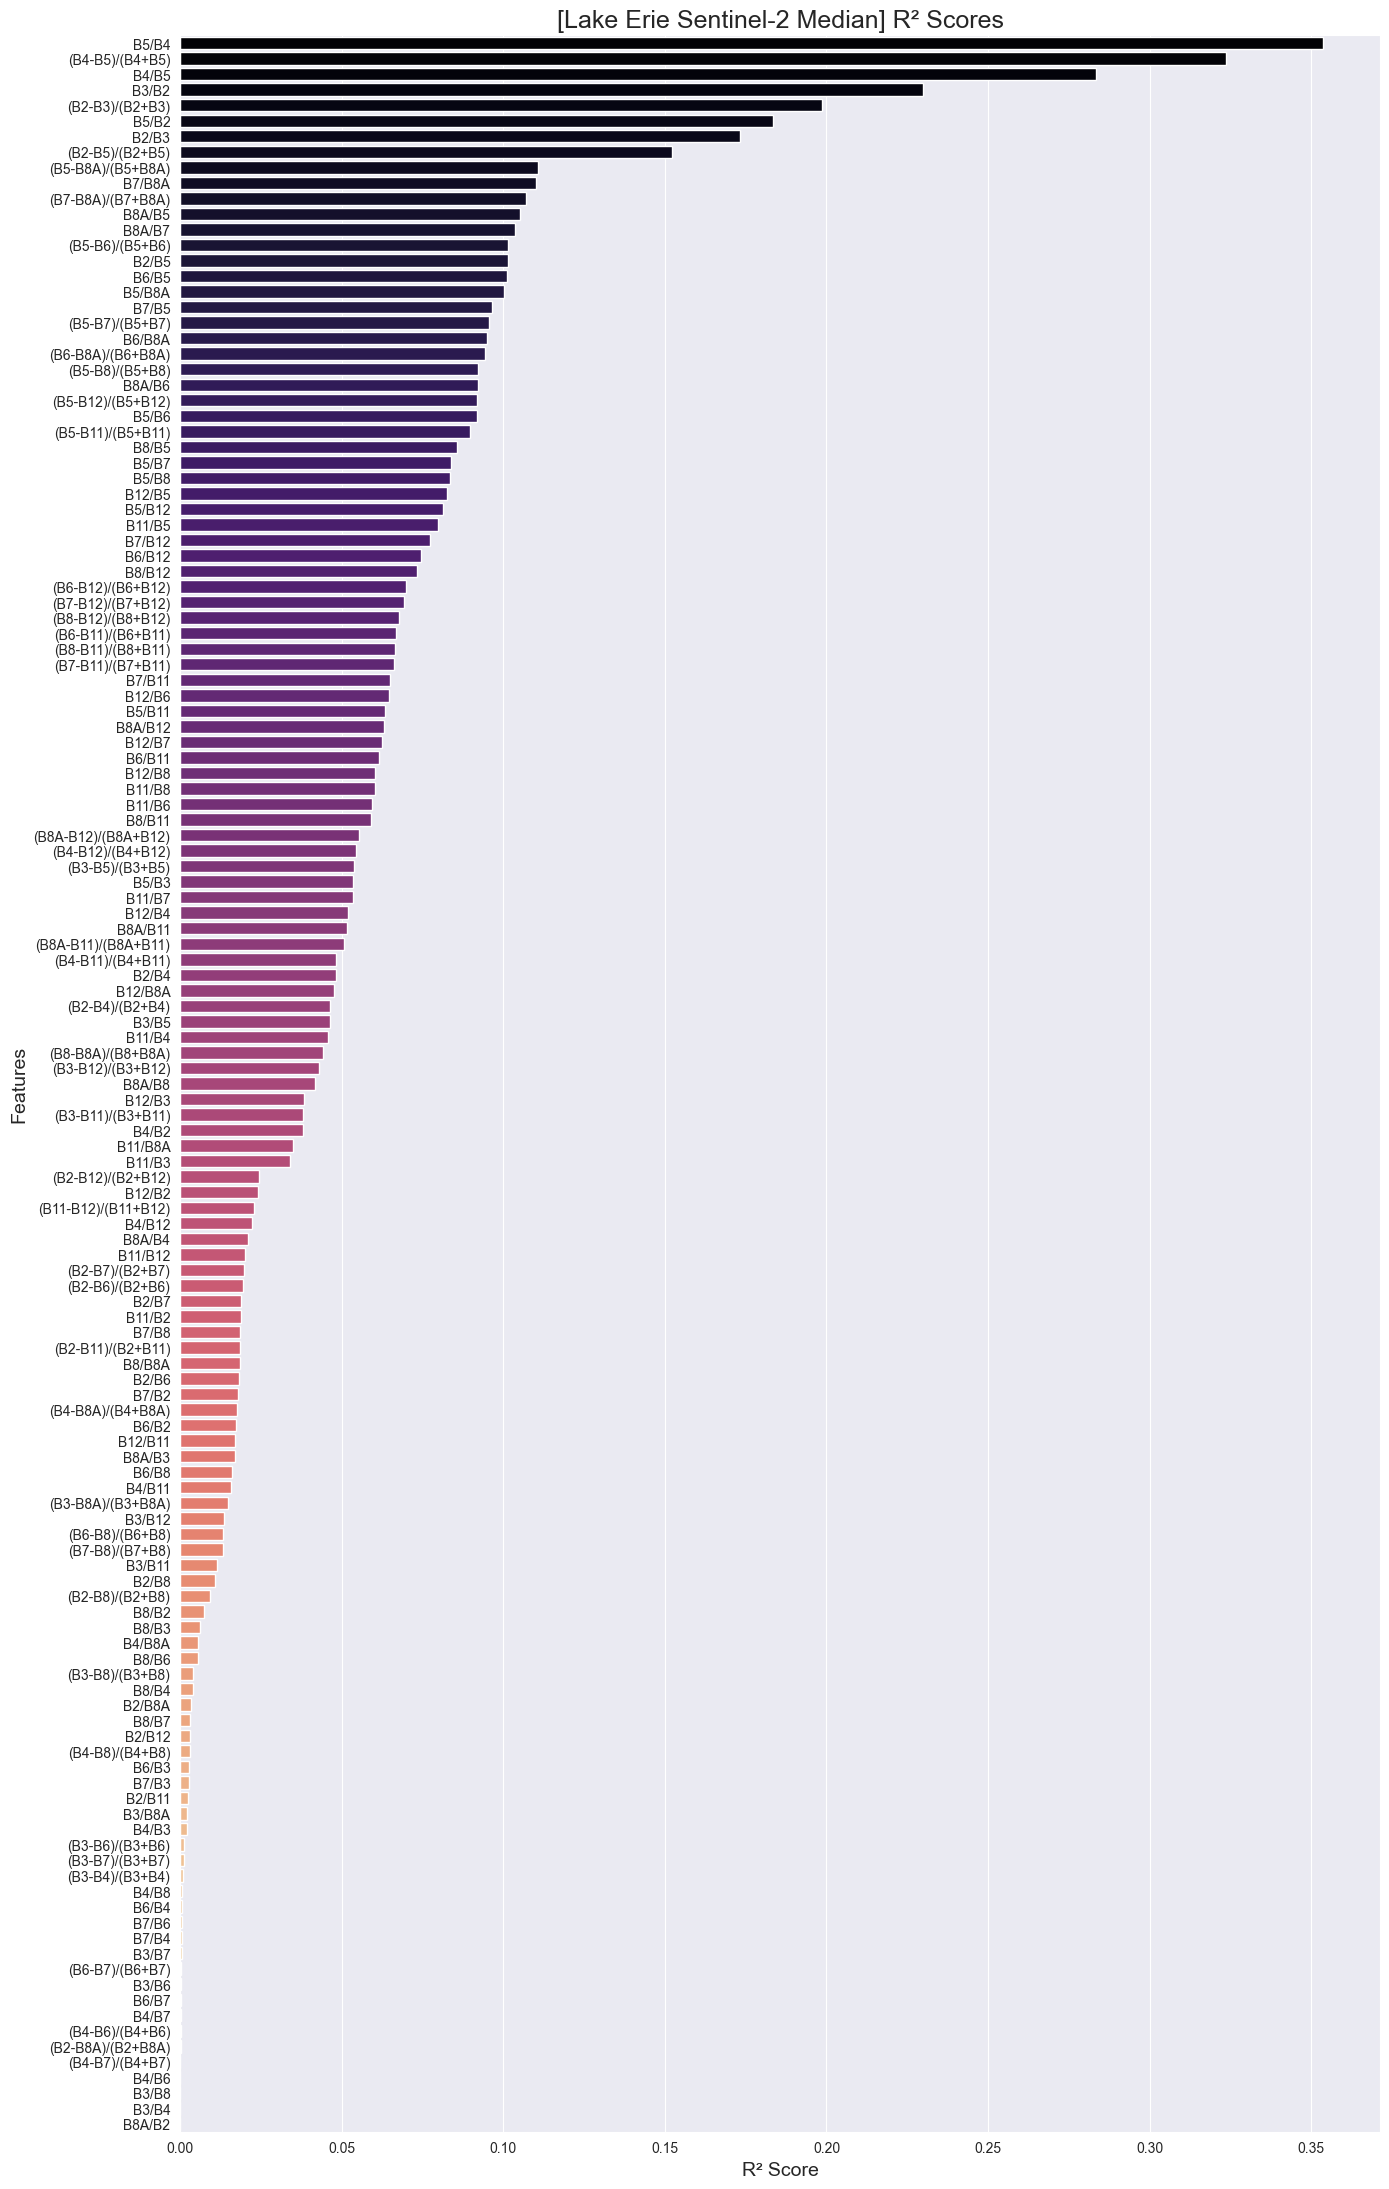

 Results successfully exported to LakeErie_S2_Median_Results.xlsx


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

file_path = "LakeErie_S2_Correlation_2015_2024-Median_Combinations.csv"
df = pd.read_csv(file_path, encoding='cp1252')


target_col = 'Target Variable(Chlorophyll-a)'


feature_cols = [col for col in df.columns if '/' in col and 'Unnamed' not in col]

data = df[[target_col] + feature_cols].dropna()
X = data[feature_cols]
y = data[target_col]

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)
importances = rf.feature_importances_

correlations = X.apply(lambda col: col.corr(y))
r2_scores = correlations ** 2

results_df = pd.DataFrame({
    'Feature': feature_cols,
    'RF_Importance': importances,
    'Correlation (r)': correlations,
    'R2_Score': r2_scores
}).sort_values(by='R2_Score', ascending=False)

print("==========================================================")
print("  [Lake Erie Median] Complete Feature Metrics (Sorted by R2)  ")
print("==========================================================")
print(results_df.to_string(index=False))
print("\n")




plt.figure(figsize=(12, 6))
rf_sorted = results_df.sort_values(by='RF_Importance', ascending=False).head(9) # Top 9 applied here
sns.barplot(x='RF_Importance', y='Feature', data=rf_sorted, palette='viridis', hue='Feature', legend=False)
plt.title('[Lake Erie Sentinel-2 Median] Top 9 Random Forest Feature Importances', fontsize=18)
plt.xlabel('Importance Score', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 22))
corr_sorted = results_df.sort_values(by='Correlation (r)', key=abs, ascending=False)
sns.barplot(x='Correlation (r)', y='Feature', data=corr_sorted, palette='coolwarm', hue='Feature', legend=False)
plt.title('[Lake Erie Sentinel-2 Median] Pearson Correlation (r)', fontsize=18)
plt.xlabel('Correlation Coefficient (r)', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 22))
r2_sorted = results_df.sort_values(by='R2_Score', ascending=False)
sns.barplot(x='R2_Score', y='Feature', data=r2_sorted, palette='magma', hue='Feature', legend=False)
plt.title('[Lake Erie Sentinel-2 Median] R² Scores', fontsize=18)
plt.xlabel('R² Score', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.tight_layout()
plt.show()


results_df.to_excel("LakeErie_S2_Median_Results.xlsx", index=False)
print(" Results successfully exported to LakeErie_S2_Median_Results.xlsx")